In [ ]:
#Loading packages required
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE
import umap
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
!ls "/content/drive"

MyDrive  Shareddrives


In [ ]:
meta_data = pd.read_csv("/content/drive/MyDrive/BT3041_Project/Copy of cancer_metadata.tsv", sep = "\t", index_col = 0)

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/BT3041_Project/Copy of RNAseq_Tumor_Data.tsv", sep = "\t", index_col = 0)

In [ ]:
# Transpose so rows = Samples, columns = Genes and clean the data
X = data.T
#Handle missing values (Fill NaNs with 0)
X = X.fillna(0)
#Remove "Constant" Genes (Genes that have 0 variance)
X = X.loc[:, (X != X.iloc[0]).any()]

gene_names = X.columns

# Standardize the data - Scaling is necessary before doing PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Transposed Data Shape: {X.shape} (Samples, Genes)")

Transposed Data Shape: (6052, 20305) (Samples, Genes)


In [ ]:
labels = []

for col in X.index:
    match = meta_data.loc[
        meta_data.index == col[0:12],
        "cancer_type"
    ]

    if not match.empty:
        labels.append(match.iloc[0])
    else:
        labels.append(None)  # or np.nan if preferred

In [ ]:
#Run PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [ ]:
# --- Scree Plot: Individual Variance Contribution ---
exp_var = pca.explained_variance_ratio_*100

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(exp_var) + 1), exp_var, color='skyblue', edgecolor='navy', alpha=0.8)
plt.title("Individual Variance Explained by Each PC", fontsize=14)
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.xticks(range(1, len(exp_var)))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# Cumulative Variance Contribution
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(exp_var) + 1), np.cumsum(exp_var), marker='o', linestyle='-', color='red', linewidth=2)
plt.axhline(y=90, color='gray', linestyle='--') # 90% threshold line
plt.text(1, 92, "90% Threshold", color='gray', fontweight='bold')
plt.title("Cumulative Variance Explained", fontsize=14)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance (%)")
plt.xticks(range(1, len(exp_var) + 1))
plt.ylim(0, 105)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
#Score Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue = labels,
    palette='tab10',
    s=120,
    edgecolor='black',
    alpha=0.9
)
plt.axhline(0, color='grey', lw=1, linestyle='--', alpha=0.5)
plt.axvline(0, color='grey', lw=1, linestyle='--', alpha=0.5)
plt.xlabel(f"PC1 ({exp_var[0]:.1f}%)", fontsize=12)
plt.ylabel(f"PC2 ({exp_var[1]:.1f}%)", fontsize=12)
plt.title("PCA Score Plot: Cancer Types", fontsize=14)
plt.legend(title="Cancer Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.1)
plt.tight_layout()
plt.show()

Shape of data fed to UMAP: (6052, 50)

Starting UMAP... (Watch the progress bar)
UMAP(n_jobs=1, random_state=42, verbose=True)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Sun May  3 11:31:13 2026 Construct fuzzy simplicial set
Sun May  3 11:31:13 2026 Finding Nearest Neighbors
Sun May  3 11:31:13 2026 Building RP forest with 9 trees
Sun May  3 11:31:22 2026 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Sun May  3 11:31:39 2026 Finished Nearest Neighbor Search
Sun May  3 11:31:44 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sun May  3 11:31:57 2026 Finished embedding
UMAP finished in 43.61 seconds.


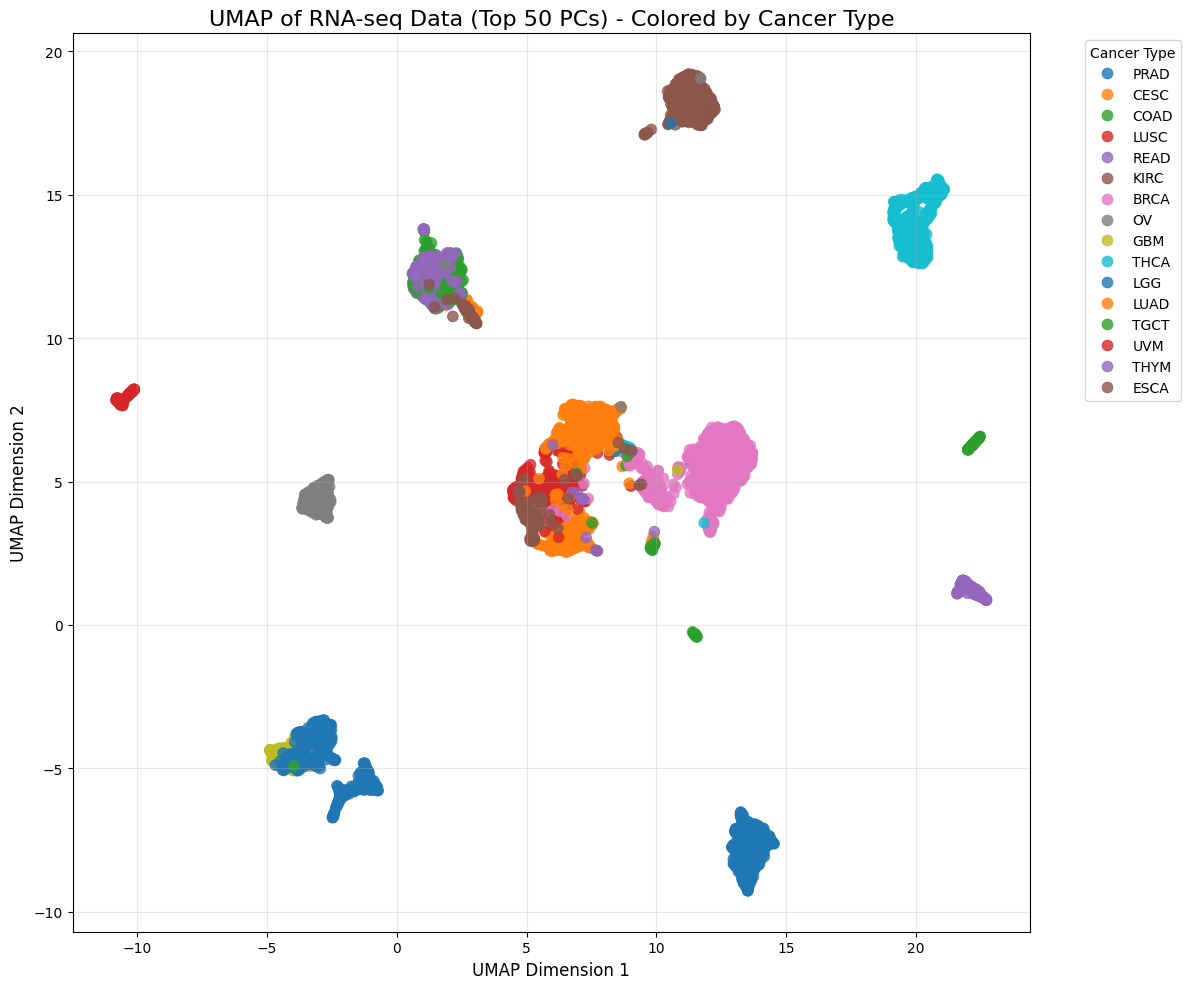

In [ ]:
import time

# 1. Isolate the Top 50 Principal Components from your existing PCA results
# This saves you from having to rerun the PCA math!
pca_50_result = X_pca[:, :50]
print(f"Shape of data fed to UMAP: {pca_50_result.shape}")

# 2. Run UMAP
print("\nStarting UMAP... (Watch the progress bar)")
umap_start = time.time()

# We use verbose=True so you can track the progress
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42, verbose=True)
umap_result = reducer.fit_transform(pca_50_result)

print(f"UMAP finished in {time.time() - umap_start:.2f} seconds.")

# 3. Create a DataFrame for plotting
umap_df = pd.DataFrame(data=umap_result, columns=['UMAP1', 'UMAP2'])
umap_df['Cancer_Type'] = labels

# 4. Plotting
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='UMAP1',
    y='UMAP2',
    hue='Cancer_Type',
    palette='tab10', # 'tab10' is great for distinct categorical labels
    data=umap_df,
    alpha=0.8,
    s=60, # Adjust dot size if necessary
    edgecolor=None
)

plt.title('UMAP of RNA-seq Data (Top 50 PCs) - Colored by Cancer Type', fontsize=16)
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)

# Move the legend outside the plot so it doesn't cover your data
plt.legend(title="Cancer Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Shape of data fed to UMAP: (6052, 70)

Starting UMAP... (Watch the progress bar)
UMAP(n_jobs=1, random_state=42, verbose=True)
Sun May  3 11:40:32 2026 Construct fuzzy simplicial set
Sun May  3 11:40:32 2026 Finding Nearest Neighbors
Sun May  3 11:40:32 2026 Building RP forest with 9 trees
Sun May  3 11:40:33 2026 NN descent for 13 iterations


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Sun May  3 11:40:33 2026 Finished Nearest Neighbor Search
Sun May  3 11:40:33 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sun May  3 11:40:57 2026 Finished embedding
UMAP finished in 24.48 seconds.


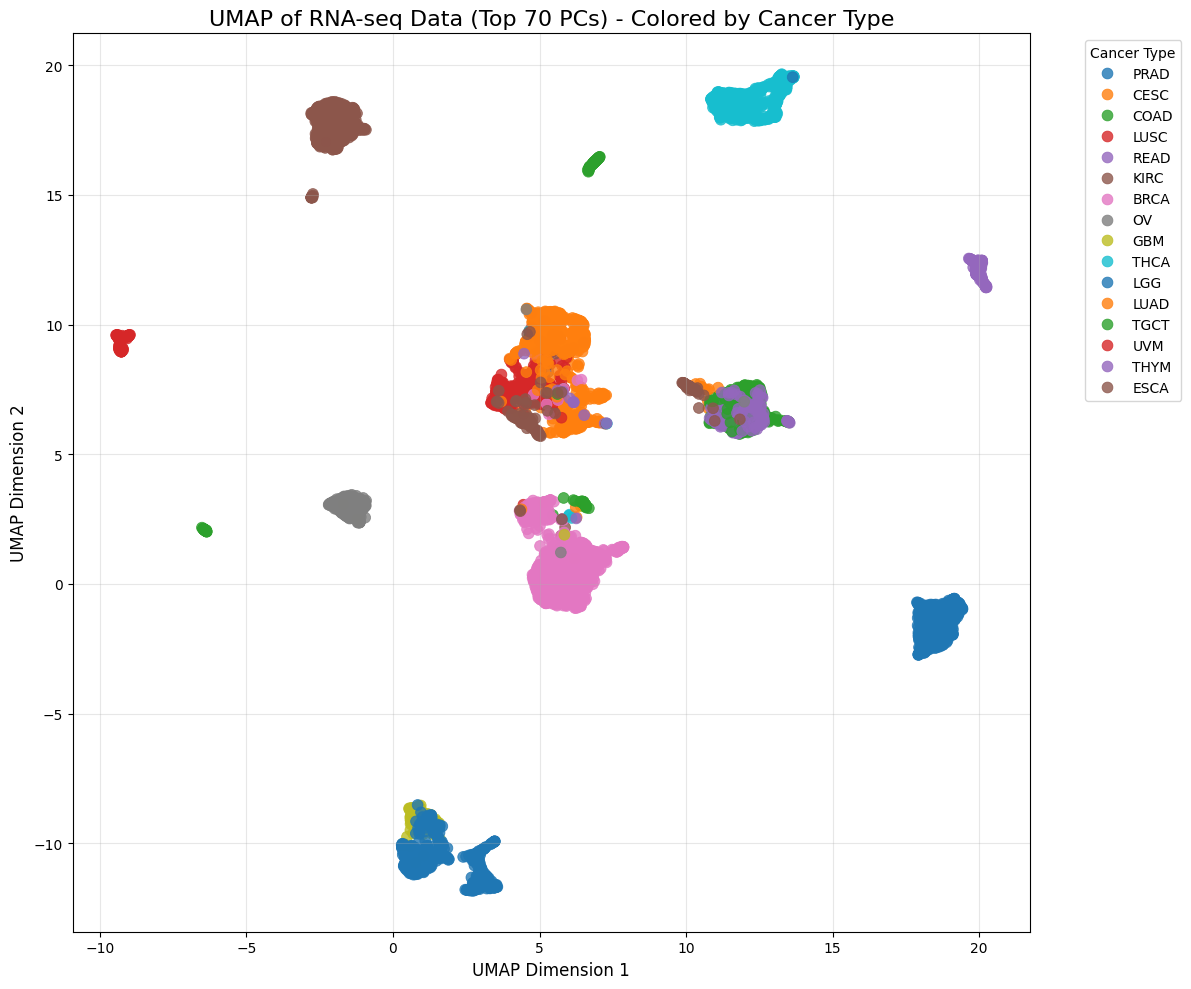

In [ ]:
import time

# 1. Isolate the Top 50 Principal Components from your existing PCA results
# This saves you from having to rerun the PCA math!
pca_50_result = X_pca[:, :70]
print(f"Shape of data fed to UMAP: {pca_50_result.shape}")

# 2. Run UMAP
print("\nStarting UMAP... (Watch the progress bar)")
umap_start = time.time()

# We use verbose=True so you can track the progress
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42, verbose=True)
umap_result = reducer.fit_transform(pca_50_result)

print(f"UMAP finished in {time.time() - umap_start:.2f} seconds.")

# 3. Create a DataFrame for plotting
umap_df = pd.DataFrame(data=umap_result, columns=['UMAP1', 'UMAP2'])
umap_df['Cancer_Type'] = labels

# 4. Plotting
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='UMAP1',
    y='UMAP2',
    hue='Cancer_Type',
    palette='tab10', # 'tab10' is great for distinct categorical labels
    data=umap_df,
    alpha=0.8,
    s=60, # Adjust dot size if necessary
    edgecolor=None
)

plt.title('UMAP of RNA-seq Data (Top 70 PCs) - Colored by Cancer Type', fontsize=16)
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)

# Move the legend outside the plot so it doesn't cover your data
plt.legend(title="Cancer Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Shape of data fed to UMAP: (6052, 250)

Starting UMAP... (Watch the progress bar)
UMAP(n_jobs=1, n_neighbors=50, random_state=42, verbose=True)
Sun May  3 11:44:23 2026 Construct fuzzy simplicial set
Sun May  3 11:44:23 2026 Finding Nearest Neighbors
Sun May  3 11:44:23 2026 Building RP forest with 9 trees
Sun May  3 11:44:23 2026 NN descent for 13 iterations


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


	 1  /  13
	 2  /  13
	Stopping threshold met -- exiting after 2 iterations
Sun May  3 11:44:29 2026 Finished Nearest Neighbor Search
Sun May  3 11:44:29 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sun May  3 11:44:52 2026 Finished embedding
UMAP finished in 29.36 seconds.


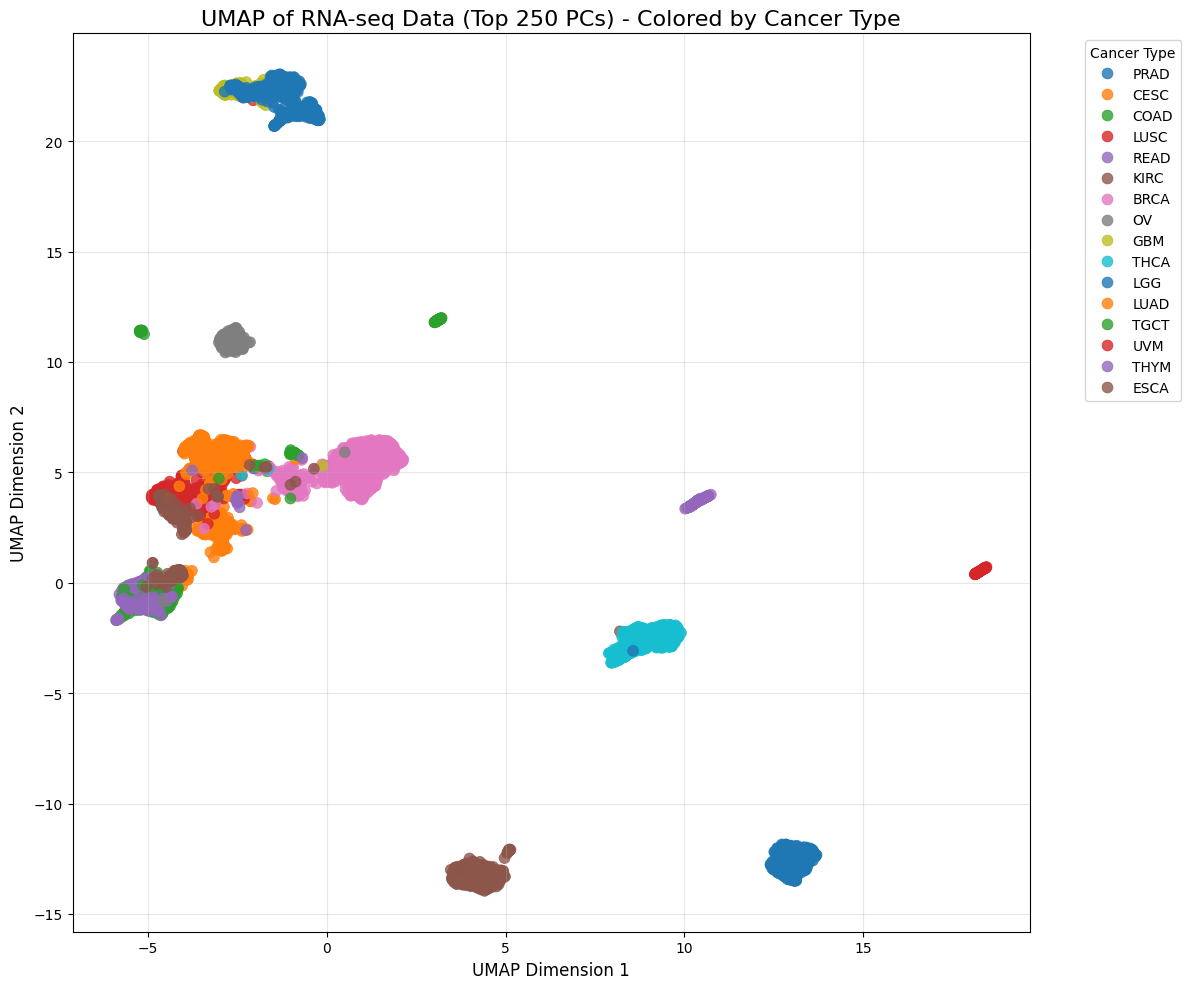

In [ ]:
import time

# 1. Isolate the Top 250 Principal Components from your existing PCA results
# This saves you from having to rerun the PCA math!
pca_50_result = X_pca[:, :250]
print(f"Shape of data fed to UMAP: {pca_50_result.shape}")

# 2. Run UMAP
print("\nStarting UMAP... (Watch the progress bar)")
umap_start = time.time()

# We use verbose=True so you can track the progress
reducer = umap.UMAP(n_neighbors=50, min_dist=0.1, random_state=42, verbose=True)
umap_result = reducer.fit_transform(pca_50_result)

print(f"UMAP finished in {time.time() - umap_start:.2f} seconds.")

# 3. Create a DataFrame for plotting
umap_df = pd.DataFrame(data=umap_result, columns=['UMAP1', 'UMAP2'])
umap_df['Cancer_Type'] = labels

# 4. Plotting
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='UMAP1',
    y='UMAP2',
    hue='Cancer_Type',
    palette='tab10', # 'tab10' is great for distinct categorical labels
    data=umap_df,
    alpha=0.8,
    s=60, # Adjust dot size if necessary
    edgecolor=None
)

plt.title('UMAP of RNA-seq Data (Top 250 PCs) - Colored by Cancer Type', fontsize=16)
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)

# Move the legend outside the plot so it doesn't cover your data
plt.legend(title="Cancer Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Shape of data fed to UMAP: (6052, 200)

Starting UMAP... (Watch the progress bar)
UMAP(n_jobs=1, n_neighbors=25, random_state=42, verbose=True)
Sun May  3 11:48:44 2026 Construct fuzzy simplicial set
Sun May  3 11:48:44 2026 Finding Nearest Neighbors
Sun May  3 11:48:44 2026 Building RP forest with 9 trees
Sun May  3 11:48:44 2026 NN descent for 13 iterations


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Sun May  3 11:48:45 2026 Finished Nearest Neighbor Search
Sun May  3 11:48:45 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sun May  3 11:48:59 2026 Finished embedding
UMAP finished in 15.49 seconds.


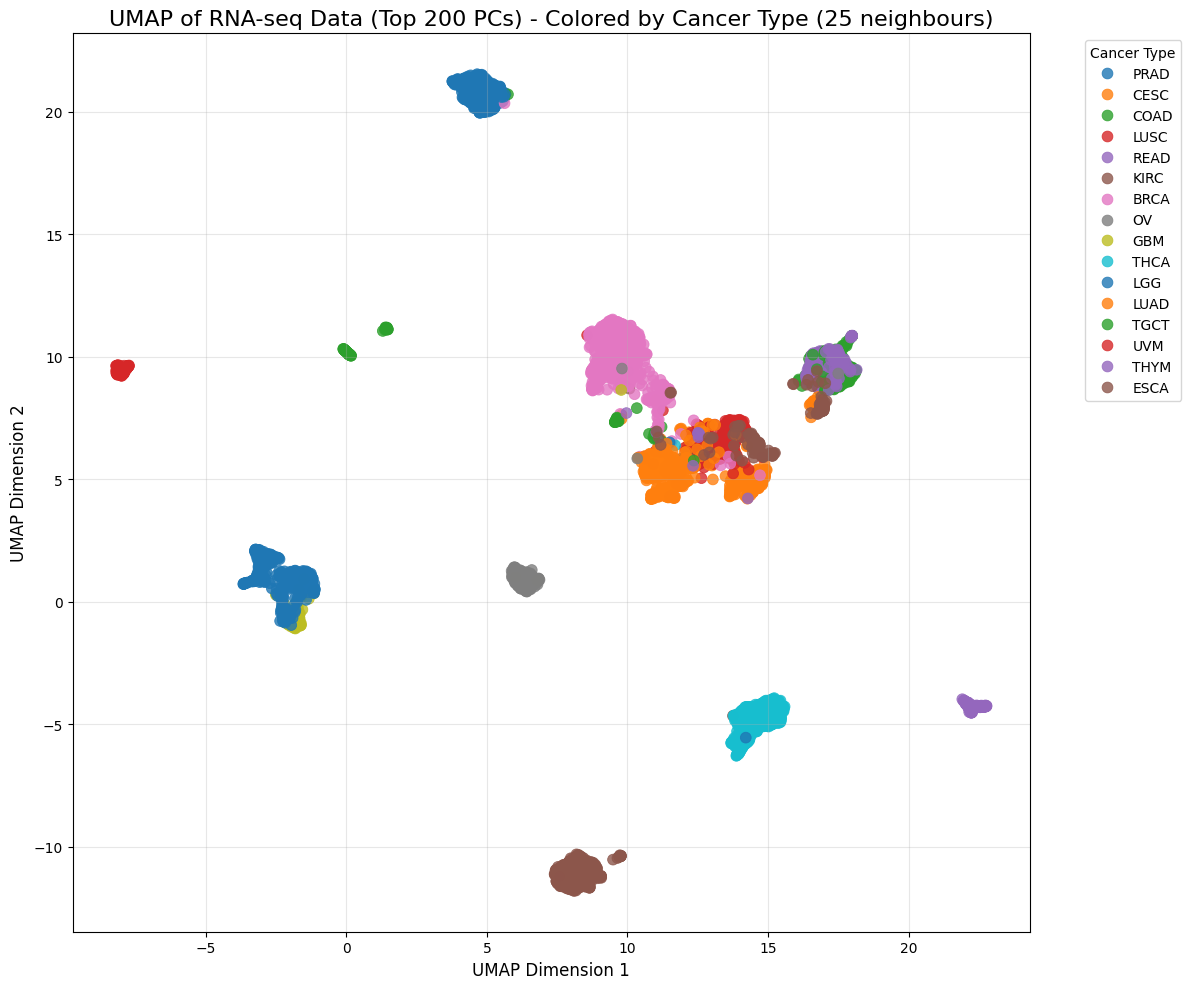

In [ ]:
import time

# 1. Isolate the Top 200 Principal Components from your existing PCA results
# This saves you from having to rerun the PCA math!
pca_50_result = X_pca[:, :200]
print(f"Shape of data fed to UMAP: {pca_50_result.shape}")

# 2. Run UMAP
print("\nStarting UMAP... (Watch the progress bar)")
umap_start = time.time()

# We use verbose=True so you can track the progress
reducer = umap.UMAP(n_neighbors=25, min_dist=0.1, random_state=42, verbose=True)
umap_result = reducer.fit_transform(pca_50_result)

print(f"UMAP finished in {time.time() - umap_start:.2f} seconds.")

# 3. Create a DataFrame for plotting
umap_df = pd.DataFrame(data=umap_result, columns=['UMAP1', 'UMAP2'])
umap_df['Cancer_Type'] = labels

# 4. Plotting
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='UMAP1',
    y='UMAP2',
    hue='Cancer_Type',
    palette='tab10', # 'tab10' is great for distinct categorical labels
    data=umap_df,
    alpha=0.8,
    s=60, # Adjust dot size if necessary
    edgecolor=None
)

plt.title('UMAP of RNA-seq Data (Top 200 PCs) - Colored by Cancer Type (25 neighbours)', fontsize=16)
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)

# Move the legend outside the plot so it doesn't cover your data
plt.legend(title="Cancer Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Shape of data fed to UMAP: (6052, 200)

Starting UMAP... (Watch the progress bar)
UMAP(n_jobs=1, n_neighbors=45, random_state=42, verbose=True)
Sun May  3 11:49:00 2026 Construct fuzzy simplicial set
Sun May  3 11:49:00 2026 Finding Nearest Neighbors
Sun May  3 11:49:00 2026 Building RP forest with 9 trees
Sun May  3 11:49:00 2026 NN descent for 13 iterations


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


	 1  /  13
	 2  /  13
	Stopping threshold met -- exiting after 2 iterations
Sun May  3 11:49:02 2026 Finished Nearest Neighbor Search
Sun May  3 11:49:02 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sun May  3 11:49:19 2026 Finished embedding
UMAP finished in 19.38 seconds.


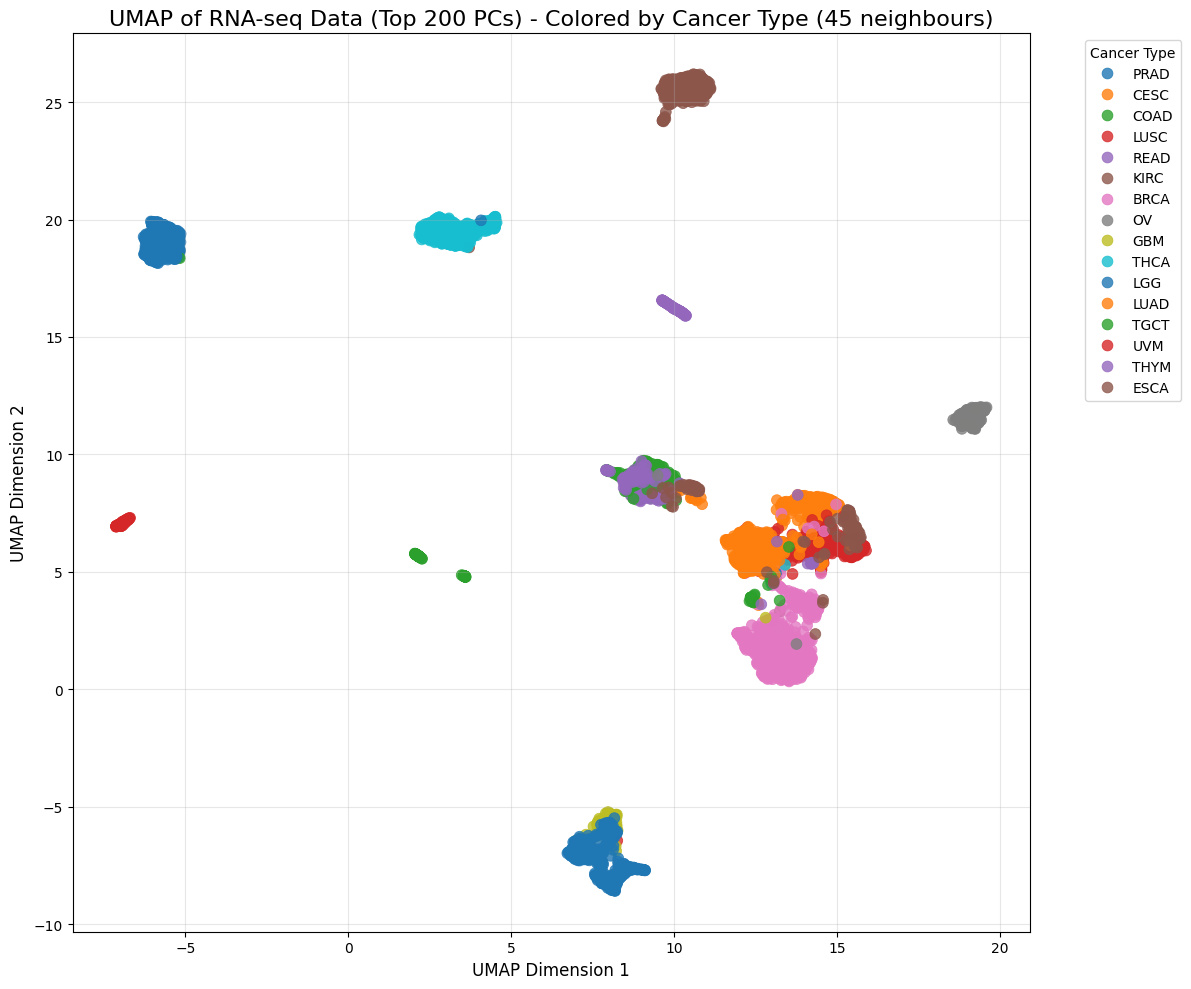

In [ ]:
import time

# 1. Isolate the Top 200 Principal Components from your existing PCA results
# This saves you from having to rerun the PCA math!
pca_50_result = X_pca[:, :200]
print(f"Shape of data fed to UMAP: {pca_50_result.shape}")

# 2. Run UMAP
print("\nStarting UMAP... (Watch the progress bar)")
umap_start = time.time()

# We use verbose=True so you can track the progress
reducer = umap.UMAP(n_neighbors=45, min_dist=0.1, random_state=42, verbose=True)
umap_result = reducer.fit_transform(pca_50_result)

print(f"UMAP finished in {time.time() - umap_start:.2f} seconds.")

# 3. Create a DataFrame for plotting
umap_df = pd.DataFrame(data=umap_result, columns=['UMAP1', 'UMAP2'])
umap_df['Cancer_Type'] = labels

# 4. Plotting
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='UMAP1',
    y='UMAP2',
    hue='Cancer_Type',
    palette='tab10', # 'tab10' is great for distinct categorical labels
    data=umap_df,
    alpha=0.8,
    s=60, # Adjust dot size if necessary
    edgecolor=None
)

plt.title('UMAP of RNA-seq Data (Top 200 PCs) - Colored by Cancer Type (45 neighbours)', fontsize=16)
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)

# Move the legend outside the plot so it doesn't cover your data
plt.legend(title="Cancer Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Shape of data fed to UMAP: (6052, 200)

Starting UMAP... (Watch the progress bar)
UMAP(n_jobs=1, n_neighbors=65, random_state=42, verbose=True)
Sun May  3 11:49:20 2026 Construct fuzzy simplicial set
Sun May  3 11:49:20 2026 Finding Nearest Neighbors
Sun May  3 11:49:20 2026 Building RP forest with 9 trees


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Sun May  3 11:49:22 2026 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	Stopping threshold met -- exiting after 2 iterations
Sun May  3 11:49:27 2026 Finished Nearest Neighbor Search
Sun May  3 11:49:27 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sun May  3 11:49:48 2026 Finished embedding
UMAP finished in 28.19 seconds.


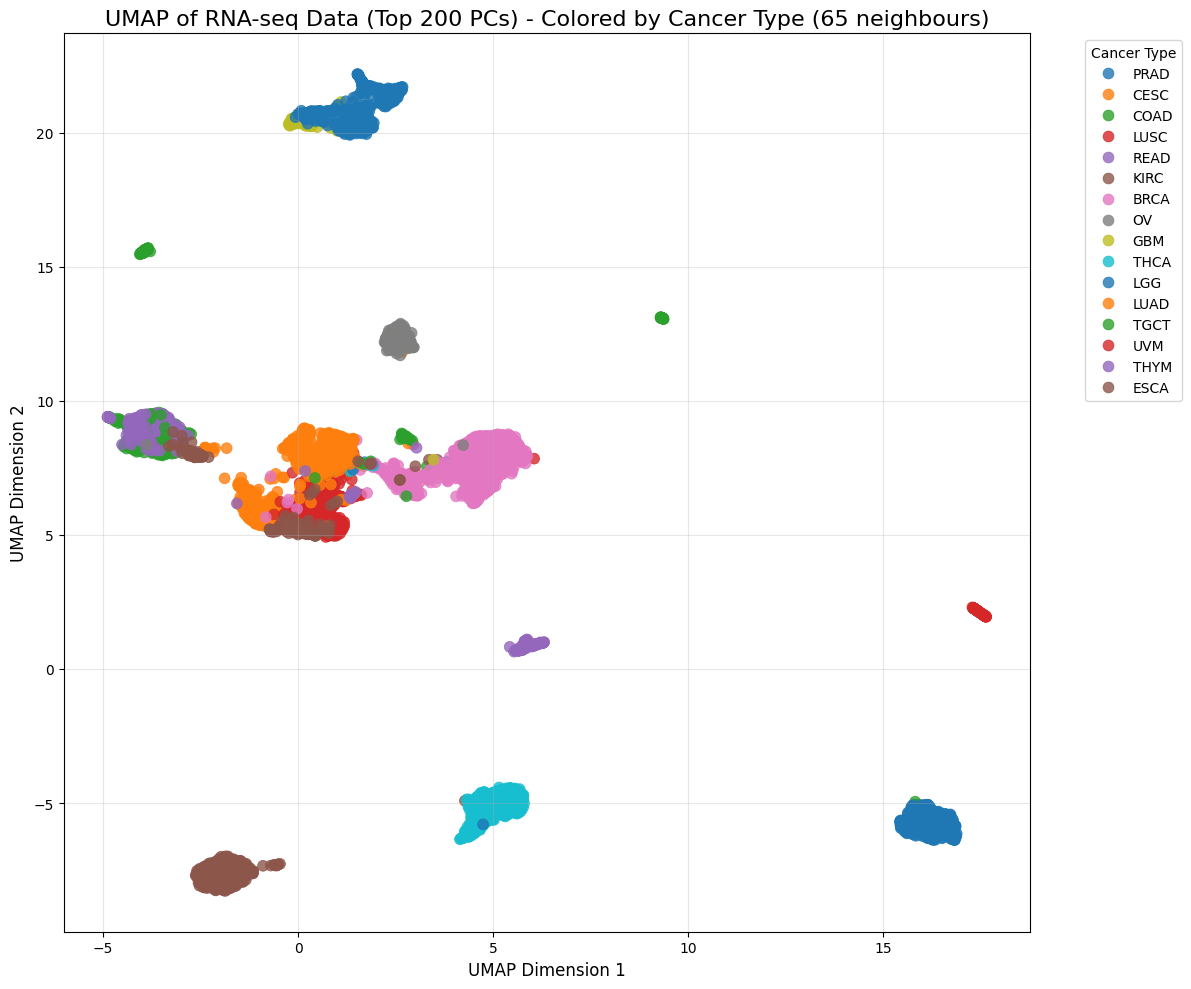

In [ ]:
import time

# 1. Isolate the Top 200 Principal Components from your existing PCA results
# This saves you from having to rerun the PCA math!
pca_50_result = X_pca[:, :200]
print(f"Shape of data fed to UMAP: {pca_50_result.shape}")

# 2. Run UMAP
print("\nStarting UMAP... (Watch the progress bar)")
umap_start = time.time()

# We use verbose=True so you can track the progress
reducer = umap.UMAP(n_neighbors=65, min_dist=0.1, random_state=42, verbose=True)
umap_result = reducer.fit_transform(pca_50_result)

print(f"UMAP finished in {time.time() - umap_start:.2f} seconds.")

# 3. Create a DataFrame for plotting
umap_df = pd.DataFrame(data=umap_result, columns=['UMAP1', 'UMAP2'])
umap_df['Cancer_Type'] = labels

# 4. Plotting
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='UMAP1',
    y='UMAP2',
    hue='Cancer_Type',
    palette='tab10', # 'tab10' is great for distinct categorical labels
    data=umap_df,
    alpha=0.8,
    s=60, # Adjust dot size if necessary
    edgecolor=None
)

plt.title('UMAP of RNA-seq Data (Top 200 PCs) - Colored by Cancer Type (65 neighbours)', fontsize=16)
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)

# Move the legend outside the plot so it doesn't cover your data
plt.legend(title="Cancer Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Shape of data fed to UMAP: (6052, 200)

Starting UMAP... (Watch the progress bar)
UMAP(n_jobs=1, n_neighbors=80, random_state=42, verbose=True)
Sun May  3 11:59:52 2026 Construct fuzzy simplicial set
Sun May  3 11:59:52 2026 Finding Nearest Neighbors
Sun May  3 11:59:52 2026 Building RP forest with 9 trees
Sun May  3 11:59:52 2026 NN descent for 13 iterations


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Sun May  3 11:59:59 2026 Finished Nearest Neighbor Search
Sun May  3 11:59:59 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Sun May  3 12:00:19 2026 Finished embedding
UMAP finished in 26.84 seconds.


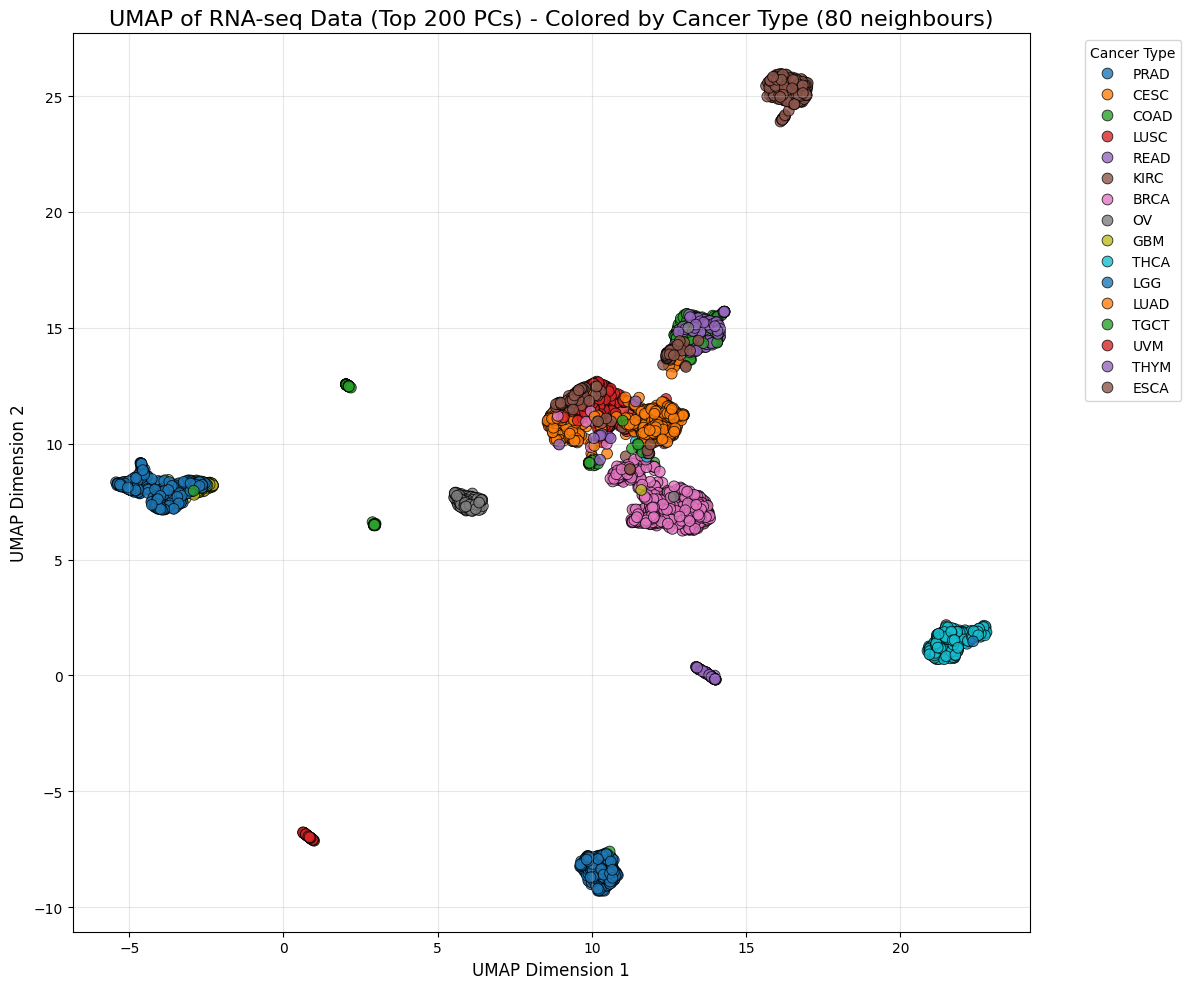

In [ ]:
import time

# 1. Isolate the Top 200 Principal Components from your existing PCA results
# This saves you from having to rerun the PCA math!
pca_50_result = X_pca[:, :200]
print(f"Shape of data fed to UMAP: {pca_50_result.shape}")

# 2. Run UMAP
print("\nStarting UMAP... (Watch the progress bar)")
umap_start = time.time()

# We use verbose=True so you can track the progress
reducer = umap.UMAP(n_neighbors=80, min_dist=0.1, random_state=42, verbose=True)
umap_result = reducer.fit_transform(pca_50_result)

print(f"UMAP finished in {time.time() - umap_start:.2f} seconds.")

# 3. Create a DataFrame for plotting
umap_df = pd.DataFrame(data=umap_result, columns=['UMAP1', 'UMAP2'])
umap_df['Cancer_Type'] = labels

# 4. Plotting
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='UMAP1',
    y='UMAP2',
    hue='Cancer_Type',
    palette='tab10', # 'tab10' is great for distinct categorical labels
    data=umap_df,
    alpha=0.8,
    s=60, # Adjust dot size if necessary
    edgecolor="black"
)

plt.title('UMAP of RNA-seq Data (Top 200 PCs) - Colored by Cancer Type (80 neighbours)', fontsize=16)
plt.xlabel("UMAP Dimension 1", fontsize=12)
plt.ylabel("UMAP Dimension 2", fontsize=12)

# Move the legend outside the plot so it doesn't cover your data
plt.legend(title="Cancer Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Shape of data fed to UMAP: (6052, 50) (Samples, Top 50 PCs)

Starting UMAP with n_neighbors=20... (Watch the progress bar)
UMAP(n_jobs=1, n_neighbors=20, random_state=42, verbose=True)
Mon May  4 04:38:29 2026 Construct fuzzy simplicial set
Mon May  4 04:38:29 2026 Finding Nearest Neighbors
Mon May  4 04:38:29 2026 Building RP forest with 9 trees
Mon May  4 04:38:29 2026 NN descent for 13 iterations


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


	 1  /  13
	 2  /  13
	Stopping threshold met -- exiting after 2 iterations
Mon May  4 04:38:30 2026 Finished Nearest Neighbor Search
Mon May  4 04:38:30 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon May  4 04:38:45 2026 Finished embedding
UMAP finished in 16.13 seconds.


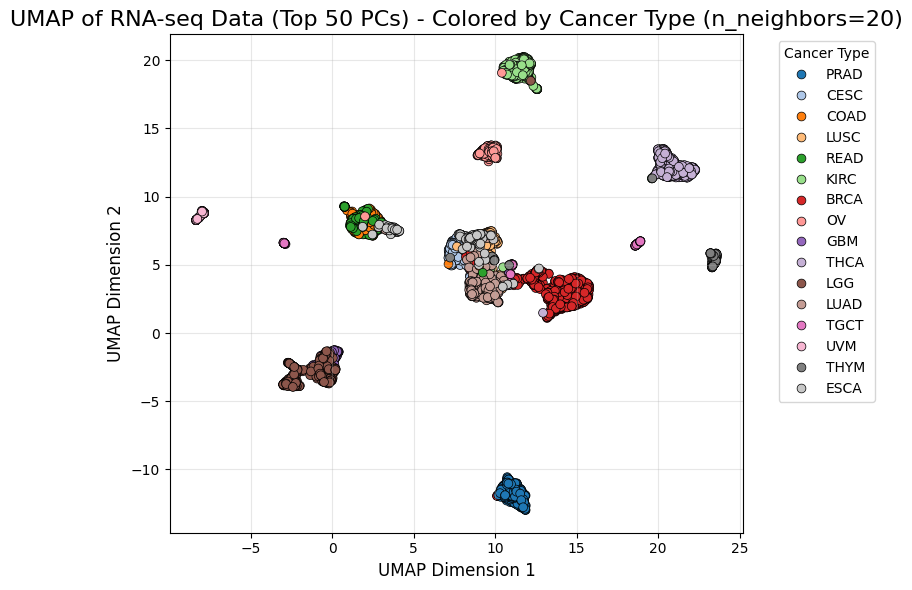


Starting UMAP with n_neighbors=30... (Watch the progress bar)
UMAP(n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Mon May  4 04:38:46 2026 Construct fuzzy simplicial set
Mon May  4 04:38:46 2026 Finding Nearest Neighbors
Mon May  4 04:38:46 2026 Building RP forest with 9 trees
Mon May  4 04:38:46 2026 NN descent for 13 iterations


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


	 1  /  13
	 2  /  13
	Stopping threshold met -- exiting after 2 iterations
Mon May  4 04:38:47 2026 Finished Nearest Neighbor Search
Mon May  4 04:38:47 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon May  4 04:39:05 2026 Finished embedding
UMAP finished in 19.24 seconds.


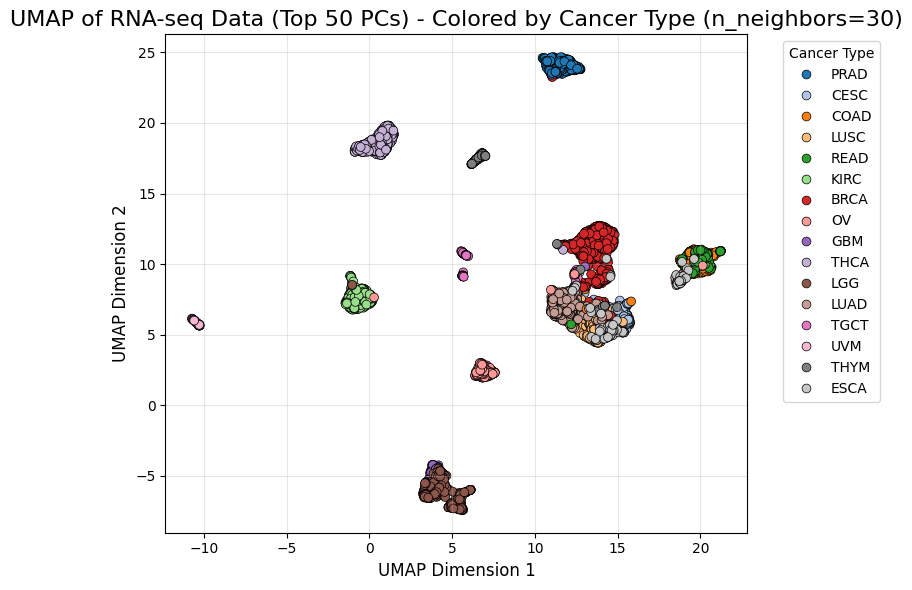


Starting UMAP with n_neighbors=40... (Watch the progress bar)
UMAP(n_jobs=1, n_neighbors=40, random_state=42, verbose=True)
Mon May  4 04:39:06 2026 Construct fuzzy simplicial set
Mon May  4 04:39:06 2026 Finding Nearest Neighbors
Mon May  4 04:39:06 2026 Building RP forest with 9 trees
Mon May  4 04:39:06 2026 NN descent for 13 iterations


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


	 1  /  13
	 2  /  13
	Stopping threshold met -- exiting after 2 iterations
Mon May  4 04:39:07 2026 Finished Nearest Neighbor Search
Mon May  4 04:39:08 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon May  4 04:39:30 2026 Finished embedding
UMAP finished in 24.04 seconds.


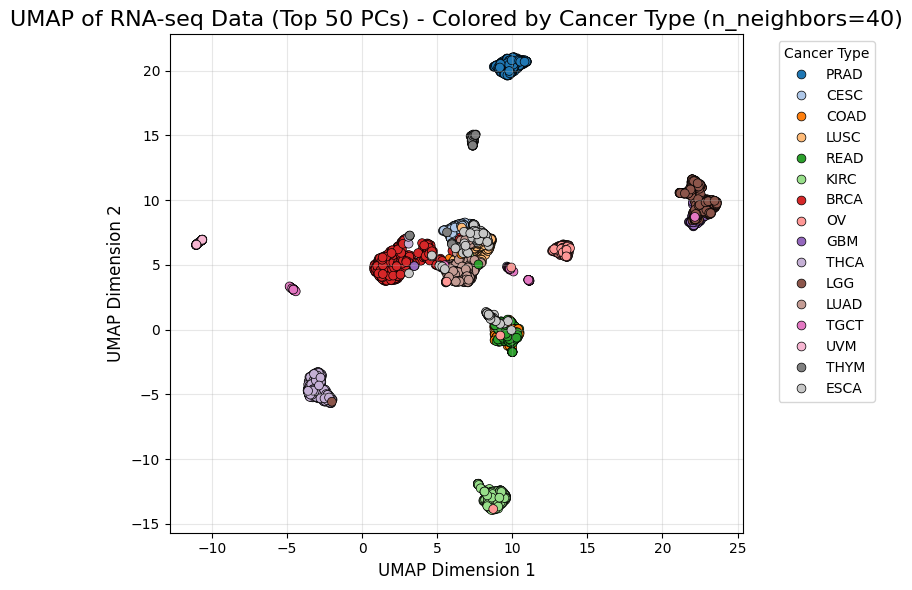


Starting UMAP with n_neighbors=50... (Watch the progress bar)
UMAP(n_jobs=1, n_neighbors=50, random_state=42, verbose=True)
Mon May  4 04:39:31 2026 Construct fuzzy simplicial set
Mon May  4 04:39:31 2026 Finding Nearest Neighbors
Mon May  4 04:39:31 2026 Building RP forest with 9 trees
Mon May  4 04:39:31 2026 NN descent for 13 iterations


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


	 1  /  13
	 2  /  13
	Stopping threshold met -- exiting after 2 iterations
Mon May  4 04:39:34 2026 Finished Nearest Neighbor Search
Mon May  4 04:39:34 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon May  4 04:39:58 2026 Finished embedding
UMAP finished in 27.07 seconds.


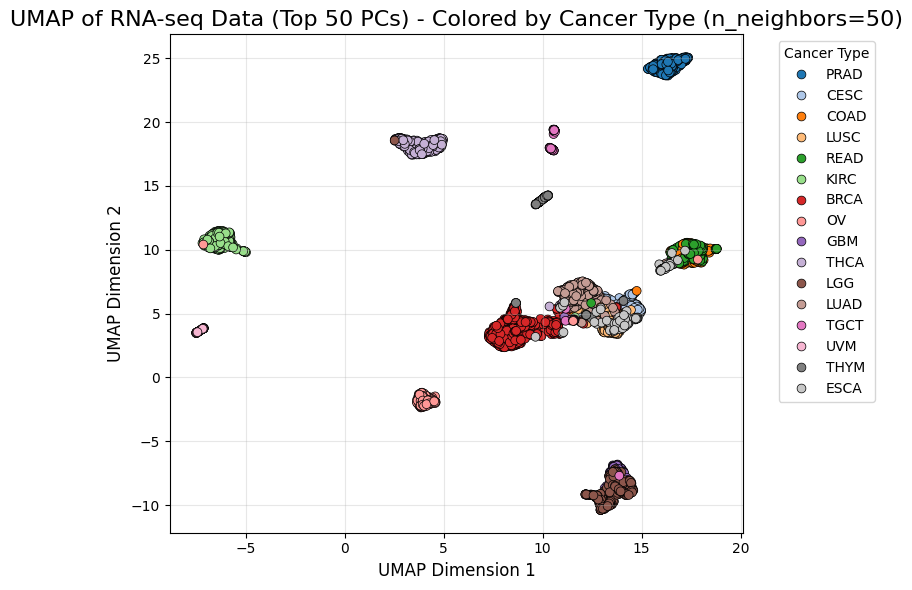


Starting UMAP with n_neighbors=60... (Watch the progress bar)
UMAP(n_jobs=1, n_neighbors=60, random_state=42, verbose=True)
Mon May  4 04:39:58 2026 Construct fuzzy simplicial set
Mon May  4 04:39:58 2026 Finding Nearest Neighbors
Mon May  4 04:39:58 2026 Building RP forest with 9 trees


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Mon May  4 04:40:02 2026 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	Stopping threshold met -- exiting after 2 iterations
Mon May  4 04:40:06 2026 Finished Nearest Neighbor Search
Mon May  4 04:40:06 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon May  4 04:40:29 2026 Finished embedding
UMAP finished in 31.20 seconds.


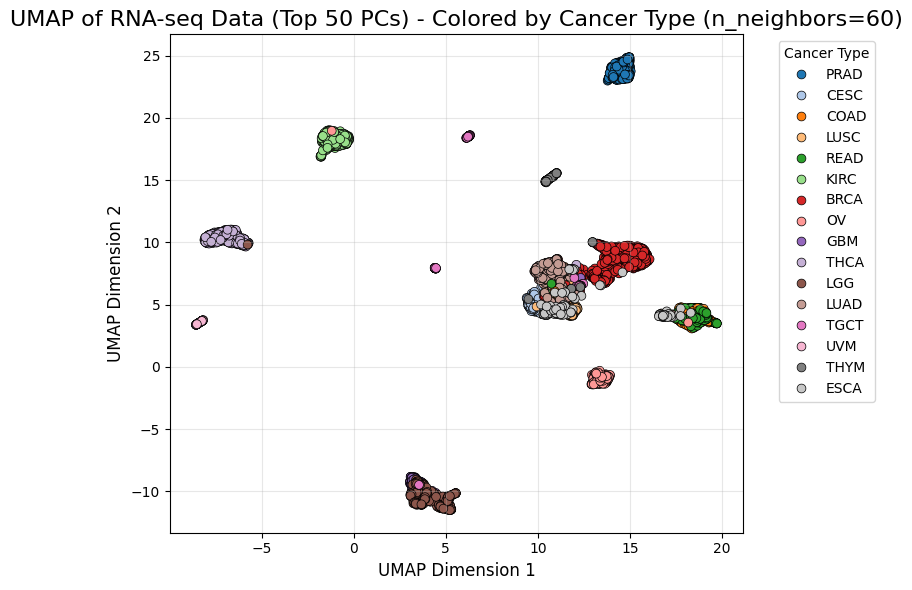

In [ ]:
import time

# 1. Isolate the Top 50 Principal Components from your existing PCA results
# This saves you from having to rerun the PCA math!
pca_50_result = X_pca[:, :50]
print(f"Shape of data fed to UMAP: {pca_50_result.shape} (Samples, Top 50 PCs)")

n_neighbors_list = [20, 30, 40, 50, 60]

for n_neighbors_val in n_neighbors_list:
    print(f"\nStarting UMAP with n_neighbors={n_neighbors_val}... (Watch the progress bar)")
    umap_start = time.time()

    # We use verbose=True so you can track the progress
    reducer = umap.UMAP(n_neighbors=n_neighbors_val, min_dist=0.1, random_state=42, verbose=True)
    umap_result = reducer.fit_transform(pca_50_result)

    print(f"UMAP finished in {time.time() - umap_start:.2f} seconds.")

    # 3. Create a DataFrame for plotting
    umap_df = pd.DataFrame(data=umap_result, columns=['UMAP1', 'UMAP2'])
    umap_df['Cancer_Type'] = labels

    # 4. Plotting
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x='UMAP1',
        y='UMAP2',
        hue='Cancer_Type',
        palette = sns.color_palette("tab20", 16), # 'tab10' is great for distinct categorical labels
        data=umap_df,
        s=40, # Adjust dot size if necessary
        edgecolor="Black"
    )

    plt.title(f'UMAP of RNA-seq Data (Top 50 PCs) - Colored by Cancer Type (n_neighbors={n_neighbors_val})', fontsize=16)
    plt.xlabel("UMAP Dimension 1", fontsize=12)
    plt.ylabel("UMAP Dimension 2", fontsize=12)

    # Move the legend outside the plot so it doesn't cover your data
    plt.legend(title="Cancer Type", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


Shape of data fed to UMAP: (6052, 25) (Samples, Top 25 PCs)
Starting UMAP with n_neighbors=20 and 25 PCs... (Watch the progress bar)
UMAP(n_jobs=1, n_neighbors=20, random_state=42, verbose=True)
Mon May  4 04:34:48 2026 Construct fuzzy simplicial set
Mon May  4 04:34:48 2026 Finding Nearest Neighbors
Mon May  4 04:34:48 2026 Building RP forest with 9 trees


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Mon May  4 04:34:54 2026 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	Stopping threshold met -- exiting after 2 iterations
Mon May  4 04:35:13 2026 Finished Nearest Neighbor Search
Mon May  4 04:35:21 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon May  4 04:35:37 2026 Finished embedding
UMAP finished in 48.80 seconds.


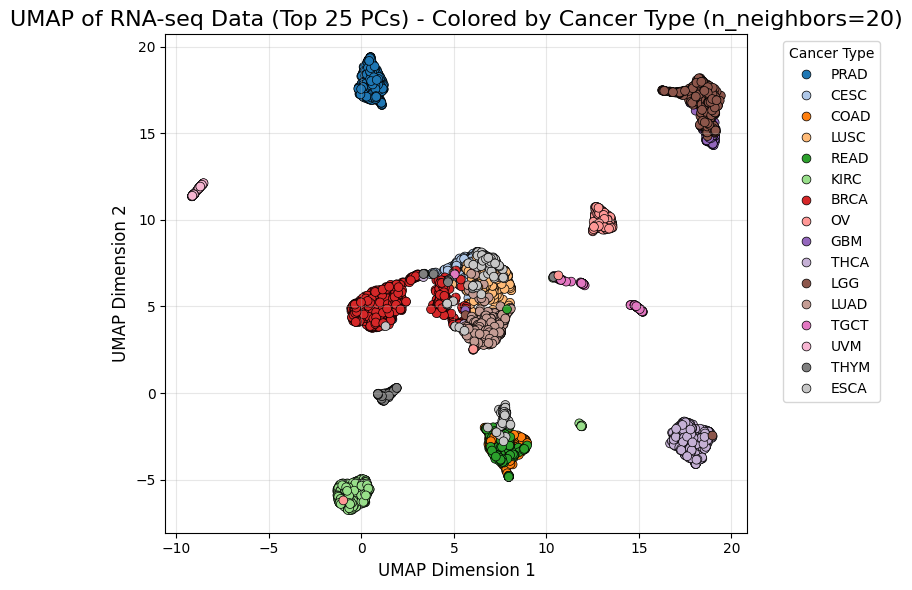


Shape of data fed to UMAP: (6052, 50) (Samples, Top 50 PCs)
Starting UMAP with n_neighbors=20 and 50 PCs... (Watch the progress bar)
UMAP(n_jobs=1, n_neighbors=20, random_state=42, verbose=True)
Mon May  4 04:35:38 2026 Construct fuzzy simplicial set
Mon May  4 04:35:38 2026 Finding Nearest Neighbors
Mon May  4 04:35:38 2026 Building RP forest with 9 trees
Mon May  4 04:35:38 2026 NN descent for 13 iterations


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


	 1  /  13
	 2  /  13
	Stopping threshold met -- exiting after 2 iterations
Mon May  4 04:35:38 2026 Finished Nearest Neighbor Search
Mon May  4 04:35:38 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon May  4 04:36:14 2026 Finished embedding
UMAP finished in 36.53 seconds.


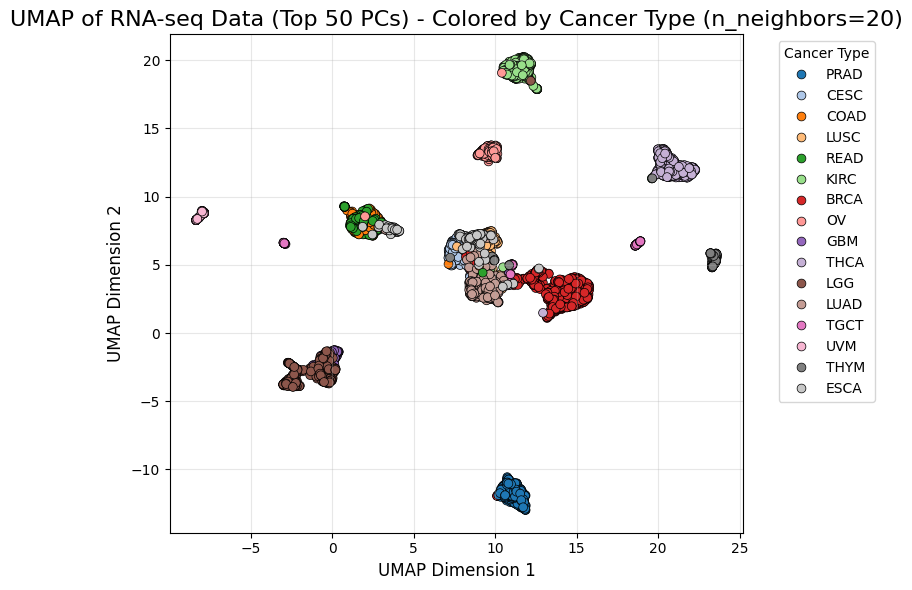


Shape of data fed to UMAP: (6052, 75) (Samples, Top 75 PCs)
Starting UMAP with n_neighbors=20 and 75 PCs... (Watch the progress bar)
UMAP(n_jobs=1, n_neighbors=20, random_state=42, verbose=True)
Mon May  4 04:36:15 2026 Construct fuzzy simplicial set
Mon May  4 04:36:15 2026 Finding Nearest Neighbors
Mon May  4 04:36:15 2026 Building RP forest with 9 trees
Mon May  4 04:36:15 2026 NN descent for 13 iterations


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


	 1  /  13
	 2  /  13
	Stopping threshold met -- exiting after 2 iterations
Mon May  4 04:36:16 2026 Finished Nearest Neighbor Search
Mon May  4 04:36:16 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon May  4 04:36:41 2026 Finished embedding
UMAP finished in 26.16 seconds.


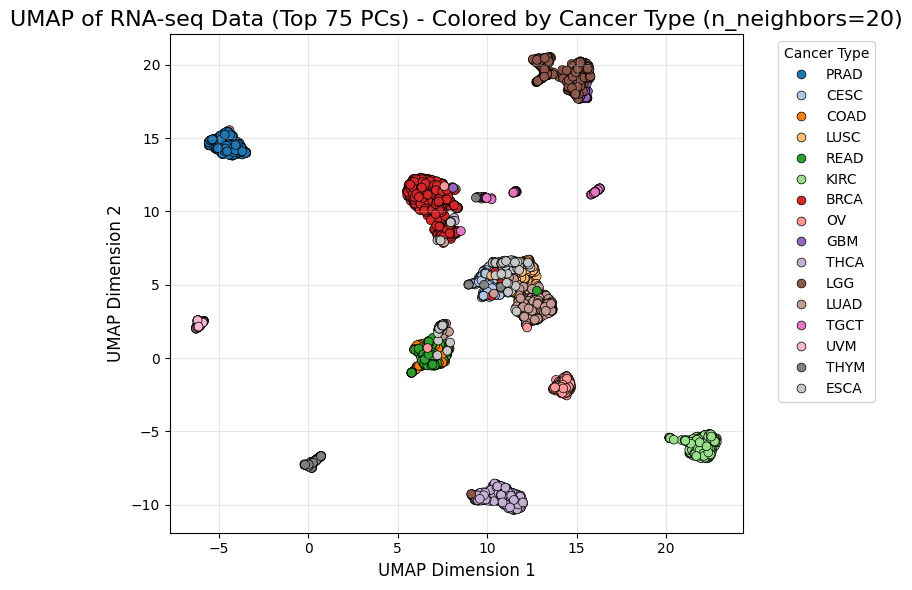


Shape of data fed to UMAP: (6052, 100) (Samples, Top 100 PCs)
Starting UMAP with n_neighbors=20 and 100 PCs... (Watch the progress bar)
UMAP(n_jobs=1, n_neighbors=20, random_state=42, verbose=True)
Mon May  4 04:36:42 2026 Construct fuzzy simplicial set
Mon May  4 04:36:42 2026 Finding Nearest Neighbors
Mon May  4 04:36:42 2026 Building RP forest with 9 trees
Mon May  4 04:36:42 2026 NN descent for 13 iterations


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Mon May  4 04:36:42 2026 Finished Nearest Neighbor Search
Mon May  4 04:36:42 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon May  4 04:37:00 2026 Finished embedding
UMAP finished in 17.80 seconds.


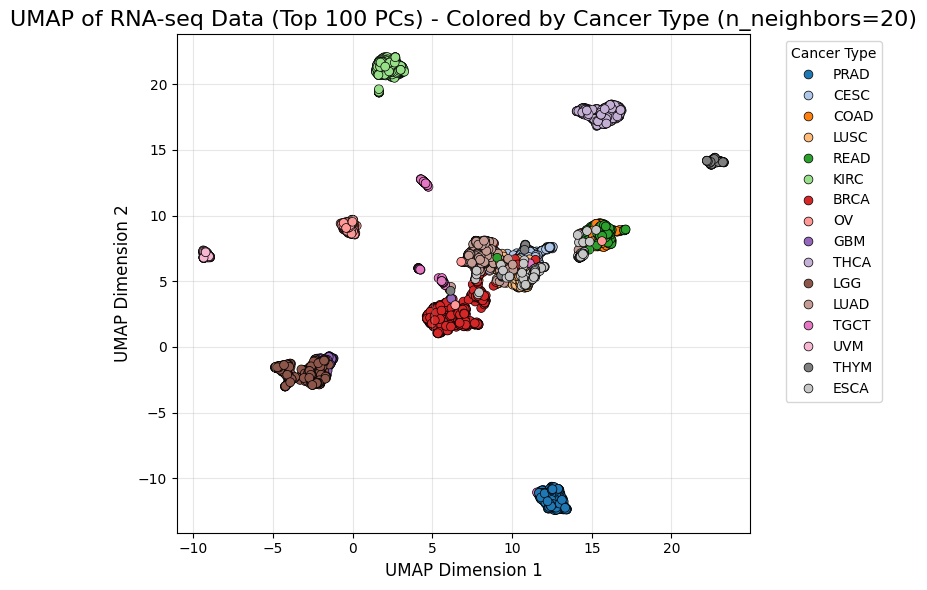


Shape of data fed to UMAP: (6052, 125) (Samples, Top 125 PCs)
Starting UMAP with n_neighbors=20 and 125 PCs... (Watch the progress bar)
UMAP(n_jobs=1, n_neighbors=20, random_state=42, verbose=True)
Mon May  4 04:37:00 2026 Construct fuzzy simplicial set
Mon May  4 04:37:00 2026 Finding Nearest Neighbors
Mon May  4 04:37:00 2026 Building RP forest with 9 trees
Mon May  4 04:37:00 2026 NN descent for 13 iterations


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Mon May  4 04:37:01 2026 Finished Nearest Neighbor Search
Mon May  4 04:37:01 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon May  4 04:37:19 2026 Finished embedding
UMAP finished in 18.83 seconds.


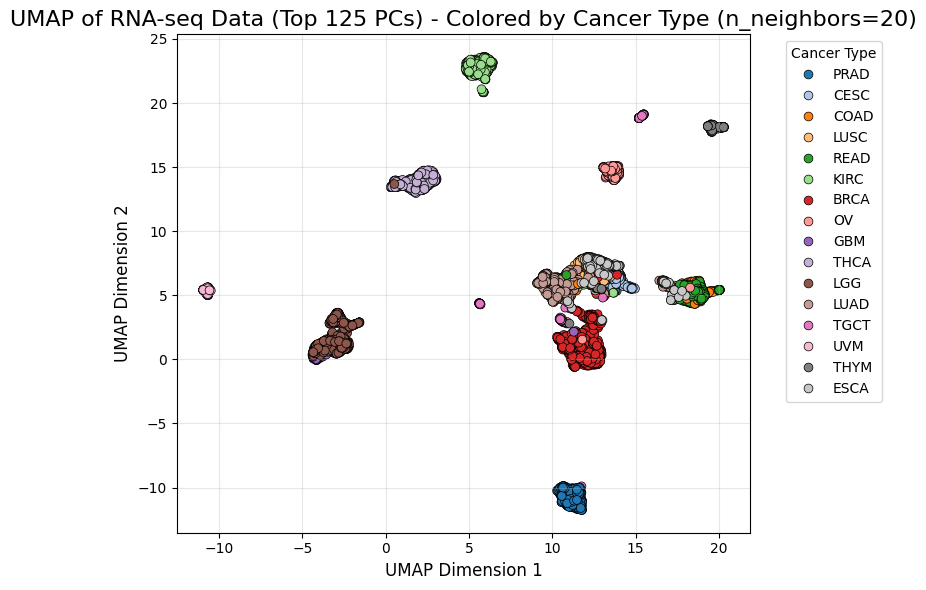


Shape of data fed to UMAP: (6052, 150) (Samples, Top 150 PCs)
Starting UMAP with n_neighbors=20 and 150 PCs... (Watch the progress bar)
UMAP(n_jobs=1, n_neighbors=20, random_state=42, verbose=True)
Mon May  4 04:37:20 2026 Construct fuzzy simplicial set
Mon May  4 04:37:20 2026 Finding Nearest Neighbors
Mon May  4 04:37:20 2026 Building RP forest with 9 trees
Mon May  4 04:37:20 2026 NN descent for 13 iterations


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Mon May  4 04:37:21 2026 Finished Nearest Neighbor Search
Mon May  4 04:37:21 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon May  4 04:37:45 2026 Finished embedding
UMAP finished in 24.97 seconds.


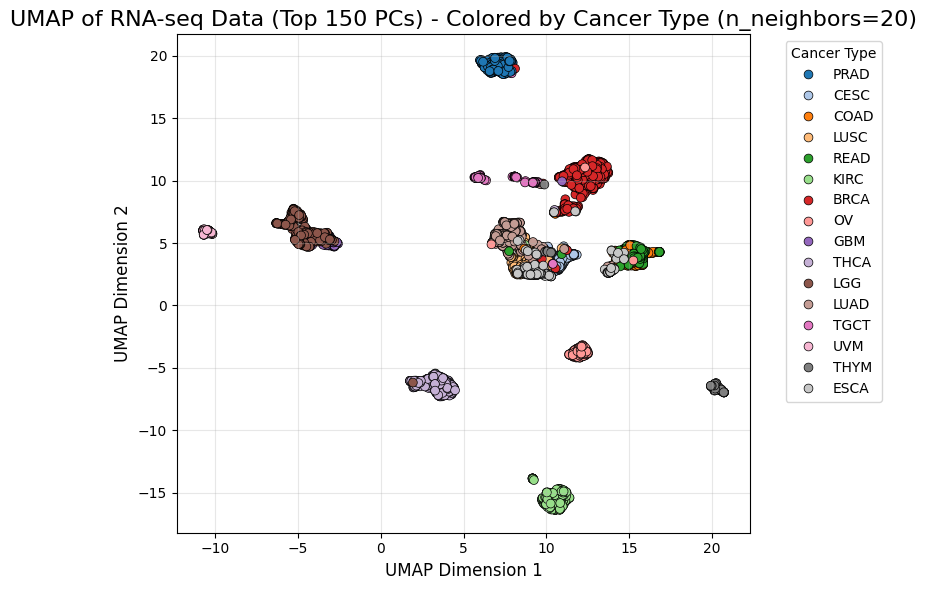


Shape of data fed to UMAP: (6052, 175) (Samples, Top 175 PCs)
Starting UMAP with n_neighbors=20 and 175 PCs... (Watch the progress bar)
UMAP(n_jobs=1, n_neighbors=20, random_state=42, verbose=True)
Mon May  4 04:37:46 2026 Construct fuzzy simplicial set
Mon May  4 04:37:46 2026 Finding Nearest Neighbors
Mon May  4 04:37:46 2026 Building RP forest with 9 trees
Mon May  4 04:37:46 2026 NN descent for 13 iterations


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Mon May  4 04:37:47 2026 Finished Nearest Neighbor Search
Mon May  4 04:37:47 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon May  4 04:38:07 2026 Finished embedding
UMAP finished in 21.56 seconds.


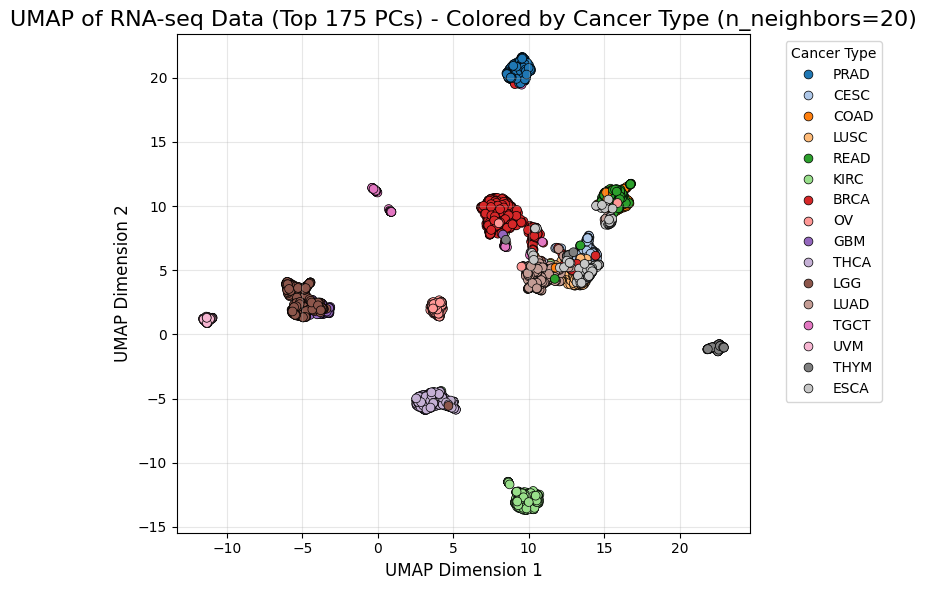


Shape of data fed to UMAP: (6052, 200) (Samples, Top 200 PCs)
Starting UMAP with n_neighbors=20 and 200 PCs... (Watch the progress bar)
UMAP(n_jobs=1, n_neighbors=20, random_state=42, verbose=True)
Mon May  4 04:38:08 2026 Construct fuzzy simplicial set
Mon May  4 04:38:08 2026 Finding Nearest Neighbors
Mon May  4 04:38:08 2026 Building RP forest with 9 trees
Mon May  4 04:38:08 2026 NN descent for 13 iterations


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


	 1  /  13
	 2  /  13
	 3  /  13
	Stopping threshold met -- exiting after 3 iterations
Mon May  4 04:38:09 2026 Finished Nearest Neighbor Search
Mon May  4 04:38:09 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Mon May  4 04:38:28 2026 Finished embedding
UMAP finished in 20.16 seconds.


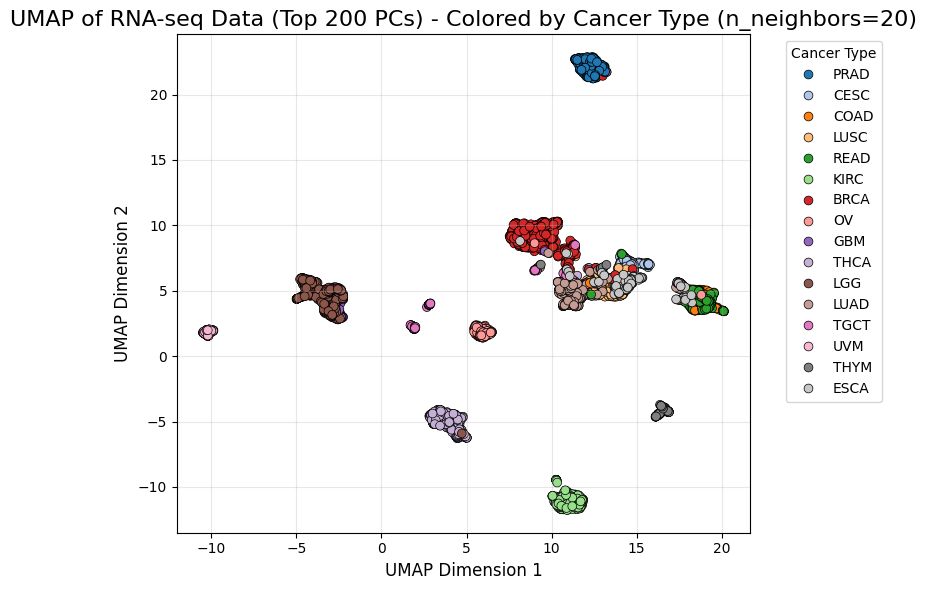

In [ ]:
import time

# Define the constant n_neighbors value
constant_n_neighbors = 20

pcs_list = [25, 50, 75, 100, 125, 150, 175, 200]

for pcs in pcs_list:
    # 1. Isolate the Top 'pcs' Principal Components from your existing PCA results
    pca_result_for_umap = X_pca[:, :pcs]
    print(f"\nShape of data fed to UMAP: {pca_result_for_umap.shape} (Samples, Top {pcs} PCs)")

    # 2. Run UMAP
    print(f"Starting UMAP with n_neighbors={constant_n_neighbors} and {pcs} PCs... (Watch the progress bar)")
    umap_start = time.time()

    # We use verbose=True so you can track the progress
    reducer = umap.UMAP(n_neighbors=constant_n_neighbors, min_dist=0.1, random_state=42, verbose=True)
    umap_result = reducer.fit_transform(pca_result_for_umap)

    print(f"UMAP finished in {time.time() - umap_start:.2f} seconds.")

    # 3. Create a DataFrame for plotting
    umap_df = pd.DataFrame(data=umap_result, columns=['UMAP1', 'UMAP2'])
    umap_df['Cancer_Type'] = labels

    # 4. Plotting
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x='UMAP1',
        y='UMAP2',
        hue='Cancer_Type',
        palette = sns.color_palette("tab20", 16), # 'tab10' is great for distinct categorical labels
        data=umap_df,
        s=40, # Adjust dot size if necessary
        edgecolor="Black"
    )

    plt.title(f'UMAP of RNA-seq Data (Top {pcs} PCs) - Colored by Cancer Type (n_neighbors={constant_n_neighbors})', fontsize=16)
    plt.xlabel("UMAP Dimension 1", fontsize=12)
    plt.ylabel("UMAP Dimension 2", fontsize=12)

    # Move the legend outside the plot so it doesn't cover your data
    plt.legend(title="Cancer Type", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()